# PseudoAlexNetTiny training and fine-tuning

## Imports to get started

In [ ]:
!pip install torchinfo
import torchinfo
import torch
import numpy as np

SEED = 317
BATCH_SIZE = 128 #test

In [2]:
from training import (
    train_model_stages,
    plot_learning_curves,
    mean_and_std_for_normalization,
    seed_everything,
    seed_worker
)

!pip install sam-pytorch
from sam import SAM

from evaluation import (
    evaluate_model
)

from fine_tuning import (
    initial_freeze_unfreeze,
    second_unfreeze,
    reset_head_last_fc
)

In [3]:
seed_everything(seed=SEED)

In [4]:
from model import PseudoAlexNet, DEVICE

In [5]:
from torchvision import datasets
from natural_images import (
    stratified_three_way_split,
    visualize_dataset_distribution,
    CutMixCollate,
    AugmentationWrapper,
    make_caltech_base_transform,
    build_caltech_split_datasets
)

from screen_images import CustomEnricoDataset

## Preparation of the data Caltech101(natural images)

In [6]:
from torchvision.transforms import v2

caltech_base_dataset = datasets.Caltech101(root="./data", download=True)
caltech_train_raw, caltech_val_raw, caltech_test_raw = stratified_three_way_split(
    dataset=caltech_base_dataset,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=SEED,
 )

caltech_preprocess = make_caltech_base_transform(resize=(300, 200))
caltech_train_raw_loader = torch.utils.data.DataLoader(
    AugmentationWrapper(caltech_train_raw, caltech_preprocess),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=3,
    worker_init_fn=seed_worker,
 )

100%|██████████| 137M/137M [00:08<00:00, 16.4MB/s]


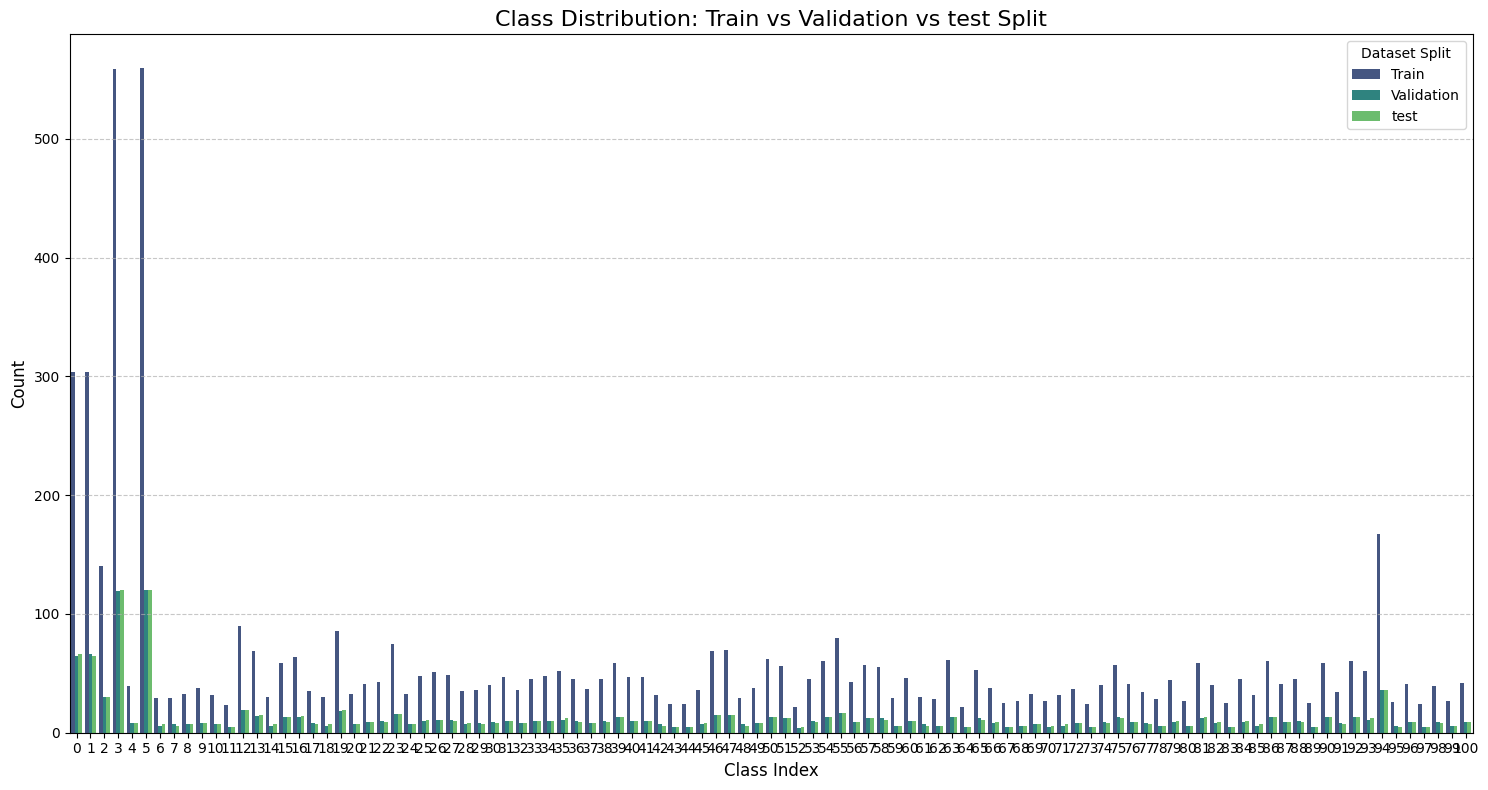

Total Training Samples:   6073 (70.0%)
Total Validation Samples: 1302 (15.0%)
Total test Samples:       1302 (15.0%)
Total Combined Samples:   8677


In [7]:
visualize_dataset_distribution(train_ds=caltech_train_raw, val_ds=caltech_val_raw, test_ds=caltech_test_raw)

In [8]:
import kornia.augmentation as K

caltech_train_mean, caltech_train_std = mean_and_std_for_normalization(caltech_train_raw_loader)

transforms_augmented_list = [
    v2.RandomResizedCrop(size=(300, 200), scale=(0.4, 1.0)),
    v2.ColorJitter(),
    v2.RandomErasing(p=1),
    K.RandomElasticTransform(p=0.3, kernel_size=(63, 63), sigma=(32.0, 32.0), keepdim=True),
    K.RandomBoxBlur(p=0.2, keepdim=True)
]

nat_images_train, nat_images_val, nat_images_test = build_caltech_split_datasets(
    train_subset=caltech_train_raw,
    val_subset=caltech_val_raw,
    test_subset=caltech_test_raw,
    mean=caltech_train_mean,
    std=caltech_train_std,
    transforms_augmented_list=transforms_augmented_list,
    resize=(300, 200),
)

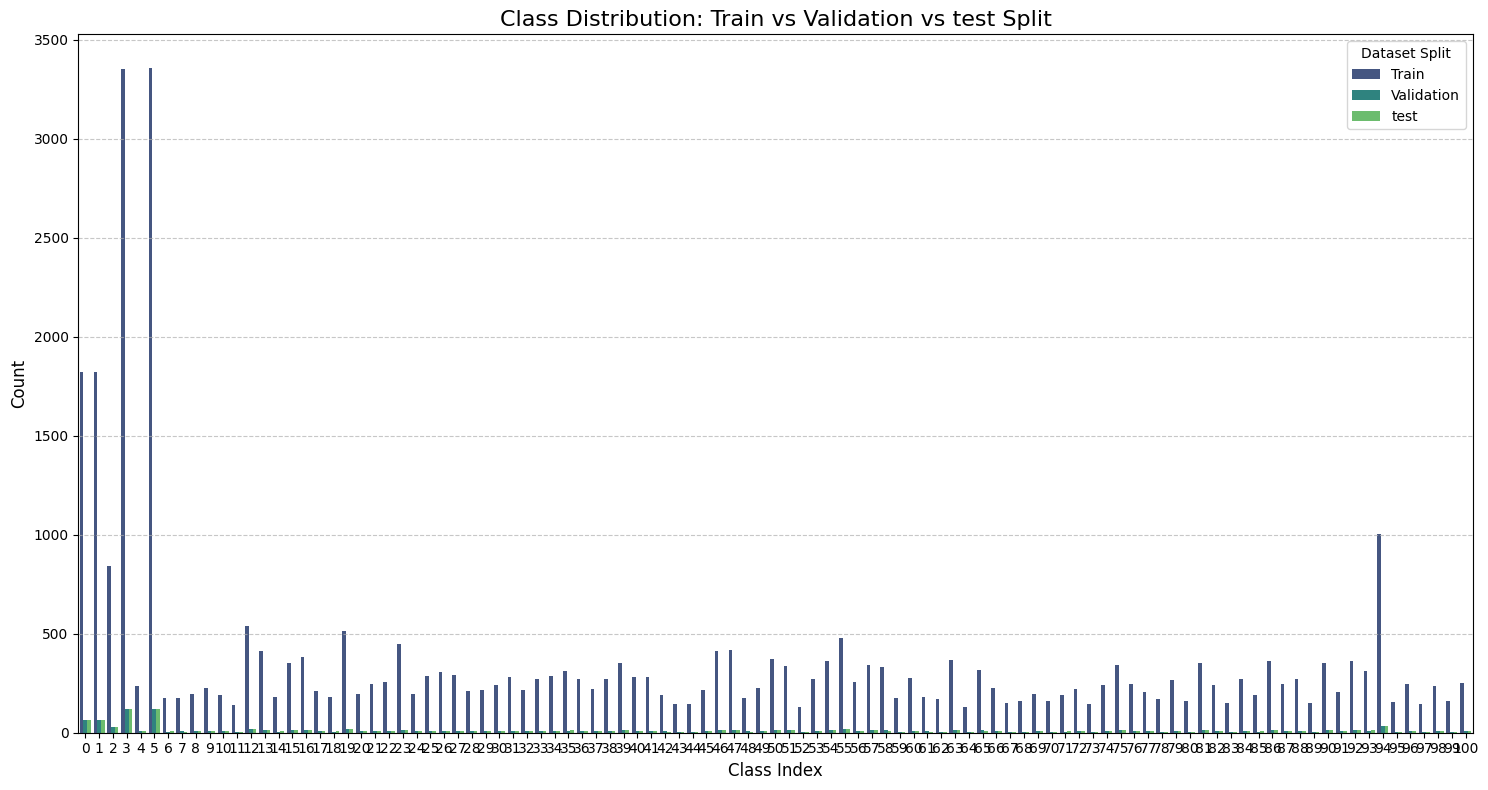

Total Training Samples:   36438 (93.3%)
Total Validation Samples: 1302 (3.3%)
Total test Samples:       1302 (3.3%)
Total Combined Samples:   39042


In [9]:
visualize_dataset_distribution(train_ds=nat_images_train, val_ds=nat_images_val, test_ds=nat_images_test)

In [10]:
g = torch.Generator()
g.manual_seed(SEED)
my_collator = CutMixCollate(num_classes=101, cutmix_prob=0.5)

nat_train_loader = torch.utils.data.DataLoader(nat_images_train, batch_size=BATCH_SIZE, shuffle=True,
                                               num_workers=3, worker_init_fn=seed_worker, 
                                               generator=g, collate_fn=my_collator)

nat_val_loader = torch.utils.data.DataLoader(nat_images_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=3)
nat_test_loader = torch.utils.data.DataLoader(nat_images_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=3)

## Training the model on Caltech101

In [11]:
import torch.optim as optim
import torch.nn as nn
MAX_NAT_EPOCHS = 50

model = PseudoAlexNet(tiny_factor=3,p=0.25) # with dropout and with LeakyReLU
print(torchinfo.summary(model))
model = model.to(DEVICE)
    
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, eps=1e-5, weight_decay=1e-3)
optimizer = SAM(
    model.parameters(), 
    optimizer, 
    rho=0.1,
 )

val_loss_list_nat = []
train_loss_list_nat = []

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  304
│    │    └─BatchNorm2d: 3-2             8
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  185
│    │    └─BatchNorm2d: 3-4             10
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  368
│    │    └─BatchNorm2d: 3-6             16
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  730
│    │    └─BatchNorm2d: 3-8             20
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       2,368,256
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropout: 

In [12]:
train_loss_list_nat, val_loss_list_nat = train_model_stages(model=model, train_loader=nat_train_loader, 
                                                            val_loader=nat_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_NAT_EPOCHS,
                                                            stage_name="nat_images", patience=7)

evaluate_model(model, nat_test_loader, loss_fn, DEVICE)

=== Training on the nat_images ===
Starting training of the nat_images in 50 epochs.
 nat_images training epoch 1/50...
Train Epoch: 1 [0/36480 (0%)]	Loss: 5.445925
Train Epoch: 1 [384/36480 (1%)]	Loss: 4.415560
Train Epoch: 1 [768/36480 (2%)]	Loss: 4.449920
Train Epoch: 1 [1152/36480 (3%)]	Loss: 3.881305
Train Epoch: 1 [1536/36480 (4%)]	Loss: 3.638274
Train Epoch: 1 [1920/36480 (5%)]	Loss: 3.479581
Train Epoch: 1 [2304/36480 (6%)]	Loss: 3.652424
Train Epoch: 1 [2688/36480 (7%)]	Loss: 4.283423
Train Epoch: 1 [3072/36480 (8%)]	Loss: 3.933587
Train Epoch: 1 [3456/36480 (9%)]	Loss: 3.315854
Train Epoch: 1 [3840/36480 (11%)]	Loss: 4.030205
Train Epoch: 1 [4224/36480 (12%)]	Loss: 4.270217
Train Epoch: 1 [4608/36480 (13%)]	Loss: 3.676359
Train Epoch: 1 [4992/36480 (14%)]	Loss: 3.570243
Train Epoch: 1 [5376/36480 (15%)]	Loss: 3.394616
Train Epoch: 1 [5760/36480 (16%)]	Loss: 3.632379
Train Epoch: 1 [6144/36480 (17%)]	Loss: 2.995672
Train Epoch: 1 [6528/36480 (18%)]	Loss: 3.513556
Train Epoch: 

(2.3178106871518223, 0.5921658986175116)

## Plotting training and validation test losses

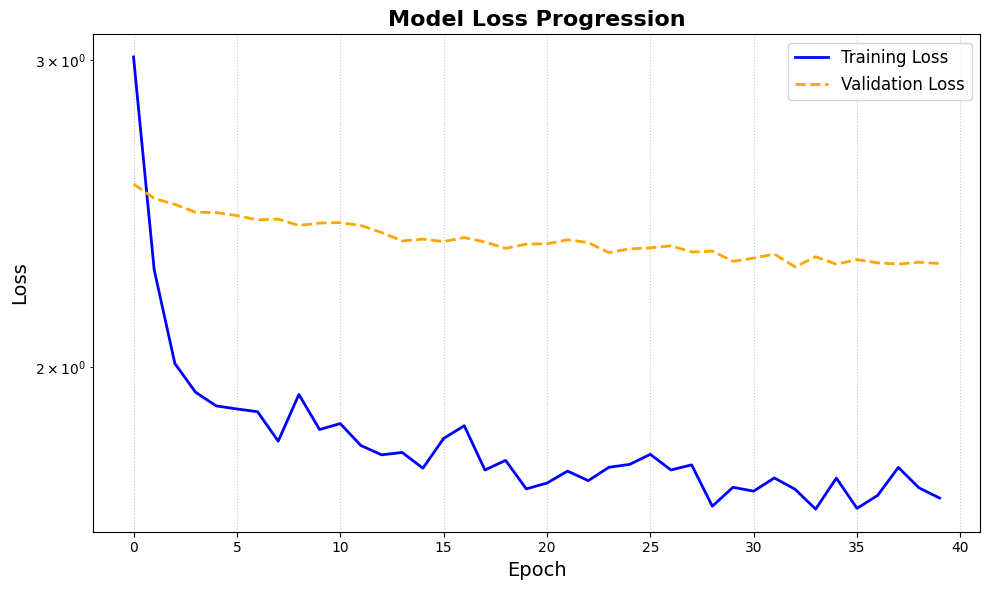

In [13]:
plot_learning_curves(train_losses=train_loss_list_nat,val_losses=val_loss_list_nat, log_scale=True, 
                     save_to_csv=True, stage="nat_images")

## Preparation of the data Enrico(screen images) - popular classes only

### 1. Defining the transformations and per class transformations for the classes that are underrepresented

In [14]:
from torchvision.transforms import v2
import random
import kornia.augmentation as K

non_identity_perms = [
    [0, 2, 1], # R-B-G
    [1, 0, 2], # G-R-B
    [1, 2, 0], # G-B-R
    [2, 0, 1], # B-R-G
    [2, 1, 0]  # B-G-R
]

forced_channel_shuffle = v2.Lambda(
    lambda x: x.data[random.choice(non_identity_perms), :, :]
)

rare_class_aug = [
    v2.RandomResizedCrop(size=(300, 200), scale=(0.4, 1.0)),
    v2.ColorJitter(),
    v2.RandomErasing(p=1),
    #K.RandomElasticTransform(p=0.3, kernel_size=(63, 63), sigma=(32.0, 32.0), keepdim=True),
    #K.RandomBoxBlur(p=0.2, keepdim=True)
]

gpu_augmentations = K.AugmentationSequential(
    K.RandomHorizontalFlip(p=0.5),
    K.RandomElasticTransform(p=0.3, kernel_size=(63, 63), sigma=(32.0, 32.0), keepdim=True),
    K.RandomBoxBlur(p=0.2, keepdim=True),

    data_keys=["input"],
    keepdim=True
).to(DEVICE)

screen_preprocess = v2.Compose([
    v2.Resize(size=(300, 200)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

## Preparation of the model for fine-tuning

### 2. Regenerating the train/val/test split for all classes

In [15]:
screen_train_raw, screen_val_raw, screen_test_raw = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes",
    seed=SEED,
    use_wireframes=True,
    train_transform=screen_preprocess,
    eval_transform=screen_preprocess,
    augment_for_each=None,
    allowed_classes=None
)

screen_raw_loader = torch.utils.data.DataLoader(
    screen_train_raw,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=3,
    worker_init_fn=seed_worker,
)

screen_train_mean, screen_train_std = mean_and_std_for_normalization(screen_raw_loader)

screen_train_transform = v2.Compose([
    screen_preprocess,
    v2.Normalize(mean=screen_train_mean, std=screen_train_std, inplace=False),
])

screen_eval_transform = screen_train_transform

full_screen_train_dataset, full_screen_val_dataset, full_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes",
    seed=SEED,
    use_wireframes=True,
    train_transform=screen_train_transform,
    eval_transform=screen_eval_transform,
    augment_for_each=rare_class_aug,
    allowed_classes=None
)

In [16]:
g = torch.Generator()
g.manual_seed(SEED)
my_collator = CutMixCollate(num_classes=20, cutmix_prob=0.5)
full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                                                       pin_memory=True, num_workers=3, worker_init_fn=seed_worker, 
                                                       generator=g, collate_fn=my_collator)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)

### 6. Preparation of the parameters for fine-tuning

In [17]:
MAX_WARMUP_EPOCHS = 15
MAX_DRIFT_EPOCHS = 40

reset_head_last_fc(model, output_features=20)
model = model.to(DEVICE)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=5*1e-5, eps=1e-5, weight_decay=1e-3)
val_loss_list_warmup_2 = []
train_loss_list_warmup_2 = []

val_loss_list_drift_2 = []
train_loss_list_drift_2 = []

### 7. Stage 1 of full classes fine-tuning

In [18]:
initial_freeze_unfreeze(model=model)

train_loss_list_warmup_2, val_loss_list_warmup_2 = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_WARMUP_EPOCHS,
                                                            stage_name="warmup_2", bn_eval=True, augmenter=gpu_augmentations)

=== Training on the warmup_2 ===
Starting training of the warmup_2 in 15 epochs.
 warmup_2 training epoch 1/15...
Train Epoch: 1 [0/4096 (0%)]	Loss: 2.993371
Train Epoch: 1 [384/4096 (9%)]	Loss: 2.925209
Train Epoch: 1 [768/4096 (19%)]	Loss: 2.879168
Train Epoch: 1 [1152/4096 (28%)]	Loss: 2.845475
Train Epoch: 1 [1536/4096 (38%)]	Loss: 2.677134
Train Epoch: 1 [1920/4096 (47%)]	Loss: 2.820929
Train Epoch: 1 [2304/4096 (56%)]	Loss: 2.629797
Train Epoch: 1 [2688/4096 (66%)]	Loss: 2.687723
Train Epoch: 1 [3072/4096 (75%)]	Loss: 2.610115
Train Epoch: 1 [3456/4096 (84%)]	Loss: 2.674987
Train Epoch: 1 [3840/4096 (94%)]	Loss: 2.757415
--- Epoch 1 Training Metrics ---
Average Train Loss: 2.765643

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 2.595041, Accuracy: 25.57%

Total time of epoch 1 is 40.26s

 warmup_2 training epoch 2/15...
Train Epoch: 2 [0/4096 (0%)]	Loss: 2.765457
Train Epoch: 2 [384/4096 (9%)]	Loss: 2.534016
Train Epoch: 2 [768/4096 (19%)]	Loss: 2.514002
Train Epoch: 2

In [19]:
second_unfreeze(model=model)

for param_group in optimizer.param_groups:
    param_group['lr'] = 2e-4
    
train_loss_list_drift_2, val_loss_list_drift_2 = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_DRIFT_EPOCHS,
                                                            stage_name="drift_2", bn_eval=True)

evaluate_model(model, full_screen_test_loader, loss_fn, DEVICE)

=== Training on the drift_2 ===
Starting training of the drift_2 in 40 epochs.
 drift_2 training epoch 1/40...
Train Epoch: 1 [0/4096 (0%)]	Loss: 1.883903
Train Epoch: 1 [384/4096 (9%)]	Loss: 2.243315
Train Epoch: 1 [768/4096 (19%)]	Loss: 1.649859
Train Epoch: 1 [1152/4096 (28%)]	Loss: 1.509768
Train Epoch: 1 [1536/4096 (38%)]	Loss: 2.189251
Train Epoch: 1 [1920/4096 (47%)]	Loss: 1.556086
Train Epoch: 1 [2304/4096 (56%)]	Loss: 2.037641
Train Epoch: 1 [2688/4096 (66%)]	Loss: 1.582668
Train Epoch: 1 [3072/4096 (75%)]	Loss: 1.642244
Train Epoch: 1 [3456/4096 (84%)]	Loss: 2.250249
Train Epoch: 1 [3840/4096 (94%)]	Loss: 2.194000
--- Epoch 1 Training Metrics ---
Average Train Loss: 1.890754

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 2.094019, Accuracy: 44.29%

Total time of epoch 1 is 38.24s

 drift_2 training epoch 2/40...
Train Epoch: 2 [0/4096 (0%)]	Loss: 1.406334
Train Epoch: 2 [384/4096 (9%)]	Loss: 1.770169
Train Epoch: 2 [768/4096 (19%)]	Loss: 1.639848
Train Epoch: 2 [11

(2.1827162504196167, 0.410958904109589)

### Plotting final train/test split

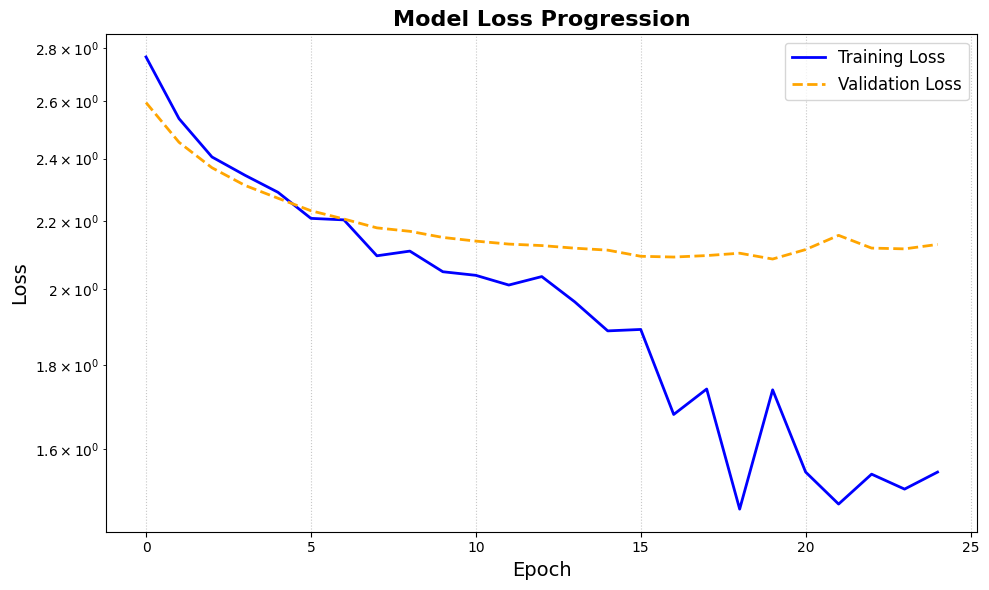

In [20]:
train_loss_list = train_loss_list_warmup_2 + train_loss_list_drift_2
val_loss_list = val_loss_list_warmup_2 + val_loss_list_drift_2

plot_learning_curves(train_losses=train_loss_list,val_losses=val_loss_list, log_scale=True,
                    save_to_csv=True, stage="drift_2")

## Training the PseudoAlexNetTiny on the Enrico for comparison

In [21]:
import torch.optim as optim
import torch.nn as nn
MAX_SCREEN_EPOCHS = 50
BATCH_SIZE = 64



In [22]:
g = torch.Generator()
g.manual_seed(SEED)
my_collator = CutMixCollate(num_classes=20, cutmix_prob=0.5)
full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                                                       pin_memory=True, num_workers=3, worker_init_fn=seed_worker,
                                                       generator=g, collate_fn=my_collator)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)

In [23]:
!pip install sam-pytorch
from sam import SAM
model = PseudoAlexNet(tiny_factor=2, p=0.25, negative_slope=0.01) # with dropout and with LeakyReLU

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
reset_head_last_fc(model, output_features=20)
model = model.to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=2e-3, eps=1e-5, weight_decay=1e-3)
#optimizer = optim.SGD(model.parameters(), lr=5e-4, momentum=0.9, weight_decay=1e-3)
optimizer = SAM(
    model.parameters(), 
    optimizer, 
    rho=0.1,
)

val_loss_list_screen = []
train_loss_list_screen = []

print(torchinfo.summary(model))

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  456
│    │    └─BatchNorm2d: 3-2             12
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  440
│    │    └─BatchNorm2d: 3-4             16
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  876
│    │    └─BatchNorm2d: 3-6             24
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  1,744
│    │    └─BatchNorm2d: 3-8             32
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       3,789,056
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropou

In [24]:
import warnings
warnings.filterwarnings("ignore")

train_loss_list_screen, val_loss_list_screen = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_SCREEN_EPOCHS,
                                                            stage_name="screen", bn_eval=False, augmenter=gpu_augmentations)

=== Training on the screen ===
Starting training of the screen in 50 epochs.
 screen training epoch 1/50...
Train Epoch: 1 [0/8192 (0%)]	Loss: 3.189322
Train Epoch: 1 [192/8192 (5%)]	Loss: 2.961953
Train Epoch: 1 [384/8192 (9%)]	Loss: 2.563226
Train Epoch: 1 [576/8192 (14%)]	Loss: 2.339052
Train Epoch: 1 [768/8192 (19%)]	Loss: 2.785694
Train Epoch: 1 [960/8192 (23%)]	Loss: 2.860855
Train Epoch: 1 [1152/8192 (28%)]	Loss: 2.435428
Train Epoch: 1 [1344/8192 (33%)]	Loss: 2.293921
Train Epoch: 1 [1536/8192 (38%)]	Loss: 2.296695
Train Epoch: 1 [1728/8192 (42%)]	Loss: 2.134472
Train Epoch: 1 [1920/8192 (47%)]	Loss: 2.273509
Train Epoch: 1 [2112/8192 (52%)]	Loss: 2.464124
Train Epoch: 1 [2304/8192 (56%)]	Loss: 2.168243
Train Epoch: 1 [2496/8192 (61%)]	Loss: 2.057395
Train Epoch: 1 [2688/8192 (66%)]	Loss: 2.395914
Train Epoch: 1 [2880/8192 (70%)]	Loss: 2.196901
Train Epoch: 1 [3072/8192 (75%)]	Loss: 2.027134
Train Epoch: 1 [3264/8192 (80%)]	Loss: 2.215465
Train Epoch: 1 [3456/8192 (84%)]	Loss: 

=== Test set: Final Average Loss: 2.149576 | Accuracy: 92/219 (42.01%) === 



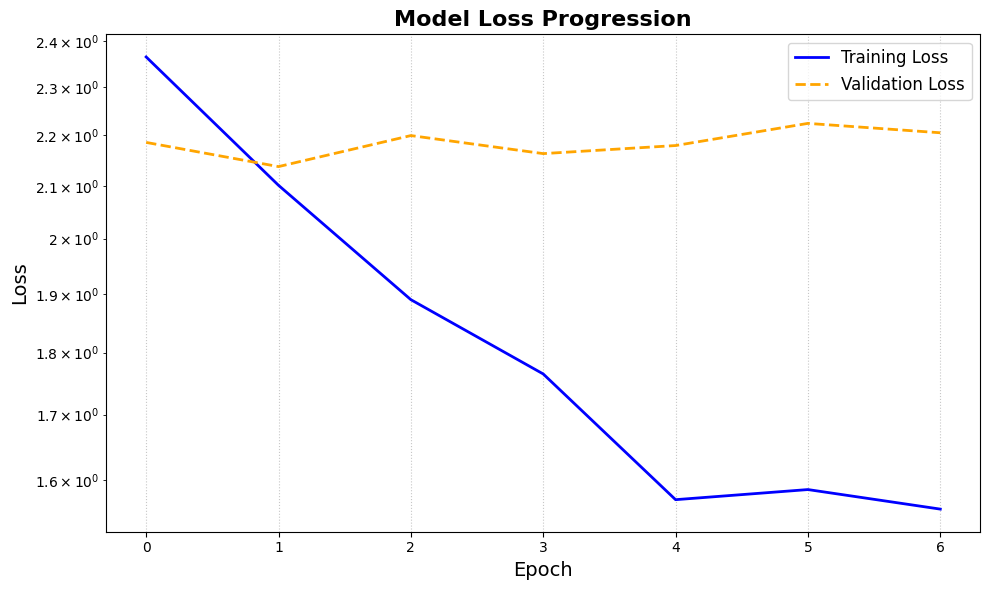

In [25]:
evaluate_model(model, full_screen_test_loader, loss_fn, DEVICE)

plot_learning_curves(train_losses=train_loss_list_screen,val_losses=val_loss_list_screen, log_scale=True,
                    save_to_csv=True, stage="screen_images")